# [ML] LightGCN bipartite vs bipartite+Twiddler 오프라인 성능 비교 — 2026-07-08

**목적**: `retail-clickstream-analysis#34`에서 LightGCN bipartite(페르소나 미결합)와 tri(페르소나 결합)를 비교한 결과, 그래프 임베딩에 페르소나를 직접 결합하는 방식은 하이퍼파라미터에 따라 효과가 있다 없다 하는 불안정한 신호였다. 재랭킹(Twiddler)으로 페르소나를 적용했을 때는 다른 결과가 나오는지, `20260708_ML_als_vs_als_twiddler_offline.ipynb`와 동일한 방법론으로 LightGCN bipartite 기준 확인한다.

이 노트북도 로직을 새로 구현하지 않는다 — `backend/api/services/persona_service.py`, `src/modeling/twiddler/rerank.py`를 ALS 노트북과 동일하게 그대로 import해서 쓴다.

| 항목 | 내용 |
|---|---|
| 데이터셋 | `data/outputs/LightGCN/PRED_MAIN_RECOMMEND.csv` (retail-clickstream-analysis#34에서 이전, 유저별 top-100 LightGCN bipartite 추천, `emb_dim=64` 1회 실행분) |
| 정답셋 | `data/outputs/LightGCN/lightgcn_test.csv` (split_date=2025-08-01 이후 **purchase** 이벤트만, ALS의 `als_test.csv`와 동일 기준) |
| 페르소나 | ALS 노트북과 동일한 `persona_service` 재사용 |
| 평가 지표 | 정확도: HR@K·Recall@K·NDCG@K (K=5,10,20) / 다양성: 세션 간 아이템 중복률, 고유 아이템 비율, 카테고리 커버리지 |
| 재현성 | `random_state=42` 고정 |

**핵심 가정 및 방법론적 제약**
- **이 추천 결과는 emb_dim=64 1회 실행분이다.** `retail-clickstream-analysis#34`에서 negative sampling에 seed가 없어 run마다 HR@20이 흔들리는 걸 확인했다(±0.002~0.005 수준) — 아래 정확도 비교 결과가 재현되는지는 아직 검증 전이다.
- Rule 3 제거, 단일 세션에서 Rule 2 미작동 등 나머지 제약은 ALS 노트북과 동일.


## 1. 하이퍼파라미터가 의미하는 것

ALS 노트북과 동일 — `configs/twiddler/params.yaml`을 그대로 로드한다.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

REPO_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(REPO_ROOT))

from backend.api.services import persona_service, catalog_service
from src.modeling.twiddler import rerank as rerank_mod
from src.modeling.als.evaluate import hit_rate_at_k, recall_at_k, ndcg_at_k

sns.set_style("whitegrid")
PALETTE = sns.color_palette("colorblind")
plt.rcParams.update({
    "font.family": "AppleGothic",  # Mac 한국어 폰트. Windows는 'Malgun Gothic', Linux는 'NanumGothic'
    "axes.unicode_minus": False,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
})

np.random.seed(42)

OUTPUT_DIR = REPO_ROOT / "data" / "outputs" / "LightGCN"
K_LIST = [5, 10, 20]
T_SESSIONS = 5  # 반복 새로고침 횟수
POOL_MULTIPLIER = rerank_mod.POOL_MULTIPLIER

In [2]:
with open(REPO_ROOT / "configs" / "twiddler" / "params.yaml", "r", encoding="utf-8") as f:
    twiddler_params = yaml.safe_load(f)
for k, v in twiddler_params.items():
    print(f"{k}: {v}")

num_categories: 7
base_alpha: 1.5
multiplier_floor: 0.3
multiplier_ceiling: 1.7
exposure_decay: 0.7
exploration_decay_min: 0.5
exploration_decay_max: 0.85
pool_multiplier: 3


Rule 1/2 파라미터의 의미는 ALS 노트북 1절 참고 — 재랭킹 로직 자체는 베이스 모델(ALS/LightGCN)과 무관하게 동일하다.

## 2. 데이터 로드 & 검증

In [3]:
recs_df = pd.read_csv(OUTPUT_DIR / "PRED_MAIN_RECOMMEND.csv")
test_df = pd.read_csv(OUTPUT_DIR / "lightgcn_test.csv")

print("[검증] PRED_MAIN_RECOMMEND.csv")
print(f"  shape={recs_df.shape}, null 비율:\n{(recs_df.isna().mean()*100).round(2).to_dict()}")
print(f"  중복 행 수: {recs_df.duplicated().sum()}")

ground_truth = test_df.groupby("user_id")["item_id"].apply(set).to_dict()
eval_users = list(ground_truth.keys())
category_map = catalog_service.get_category_map()

recs_by_user = {
    uid: g.sort_values("rank")[["item_id", "score"]].to_dict("records")
    for uid, g in recs_df[recs_df["user_id"].isin(eval_users)].groupby("user_id")
}
print(f"\n평가 대상 유저 수: {len(eval_users):,}명, 추천 보유 유저: {len(recs_by_user):,}명")

[검증] PRED_MAIN_RECOMMEND.csv
  shape=(2000000, 5), null 비율:
{'user_id': 0.0, 'item_id': 0.0, 'score': 0.0, 'rank': 0.0, 'model_type': 0.0}
  중복 행 수: 0



평가 대상 유저 수: 1,465명, 추천 보유 유저: 1,465명


## 3. 단일 세션(1회 추천) 정확도: bipartite only vs bipartite+Twiddler

실제 서빙 코드와 동일한 순서로 호출한다: `persona_service.get_persona` → `get_user_affinity`/`get_user_alpha` → `rerank_mod.rerank`.
`exposure_counts=None`이라 Rule 2는 이 단계에서 작동하지 않는다(첫 요청 가정).

In [4]:
def apply_current_twiddler(candidates, uid, k):
    persona_label = persona_service.get_persona(uid)
    if persona_label is None:
        return [it["item_id"] for it in candidates[:k]]
    affinity = persona_service.get_user_affinity(uid)
    alpha = persona_service.get_user_alpha(uid)
    reranked = rerank_mod.rerank(
        candidates, id_key="item_id", category_map=category_map,
        affinity=affinity, alpha=alpha, exposure_counts=None, top_k=k,
    )
    return [it["item_id"] for it in reranked]


def single_session_metrics(k, condition):
    pool_n = k * POOL_MULTIPLIER
    hr_list, recall_list, ndcg_list = [], [], []
    for uid in eval_users:
        if uid not in recs_by_user:
            continue
        candidates = [dict(it) for it in recs_by_user[uid][:pool_n]]
        if condition == "bipartite_only":
            recommended = [it["item_id"] for it in candidates[:k]]
        else:
            recommended = apply_current_twiddler(candidates, uid, k)
        true_items = ground_truth[uid]
        hr_list.append(hit_rate_at_k(recommended, true_items))
        recall_list.append(recall_at_k(recommended, true_items))
        ndcg_list.append(ndcg_at_k(recommended, true_items))
    return {"k": k, "condition": condition, "HR": round(np.mean(hr_list), 4),
            "Recall": round(np.mean(recall_list), 4), "NDCG": round(np.mean(ndcg_list), 4),
            "eval_users": len(hr_list)}


baseline_rows = [single_session_metrics(k, c) for k in K_LIST for c in ["bipartite_only", "bipartite_twiddler"]]
baseline_df = pd.DataFrame(baseline_rows)
print(baseline_df.to_string(index=False))

 k          condition     HR  Recall   NDCG  eval_users
 5     bipartite_only 0.0068  0.0029 0.0021        1465
 5 bipartite_twiddler 0.0075  0.0025 0.0020        1465
10     bipartite_only 0.0225  0.0091 0.0047        1465
10 bipartite_twiddler 0.0232  0.0109 0.0052        1465
20     bipartite_only 0.0485  0.0225 0.0087        1465
20 bipartite_twiddler 0.0553  0.0291 0.0107        1465


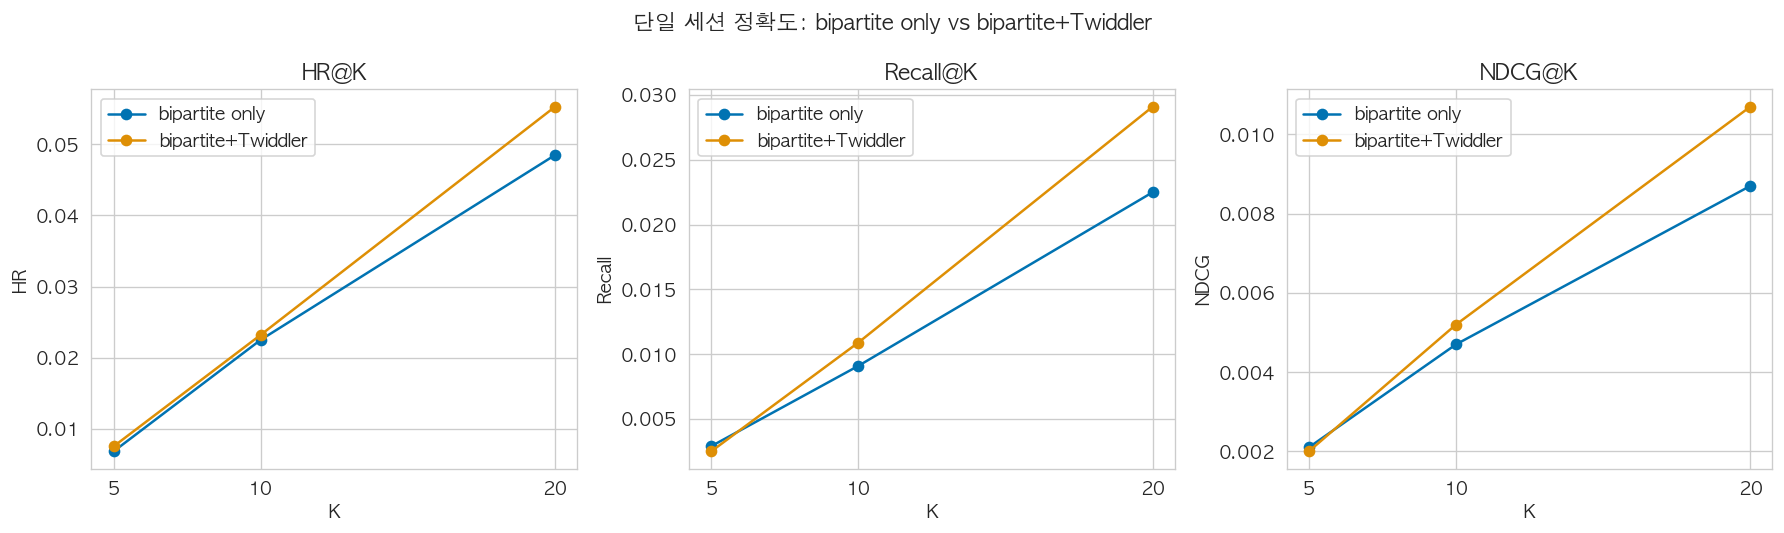

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics = ["HR", "Recall", "NDCG"]
for ax, metric in zip(axes, metrics):
    for i, cond in enumerate(["bipartite_only", "bipartite_twiddler"]):
        vals = baseline_df[baseline_df["condition"] == cond].sort_values("k")[metric].values
        ax.plot(K_LIST, vals, marker="o", label={"bipartite_only": "bipartite only", "bipartite_twiddler": "bipartite+Twiddler"}[cond], color=PALETTE[i])
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric}@K")
    ax.set_xticks(K_LIST)
    ax.legend()
fig.suptitle("단일 세션 정확도: bipartite only vs bipartite+Twiddler", fontsize=13)
plt.tight_layout()
plt.show()

ALS+Twiddler와 달리 K에 따라 방향이 엇갈리지 않는다 — K=5에서는 HR만 소폭 개선(+10.3%)되고 Recall/NDCG는 소폭 하락하지만, K=10부터는 세 지표 모두 개선되고(HR +3.1%, Recall +19.8%, NDCG +10.6%) K=20에서 가장 뚜렷하다(HR +14.0%, Recall +29.3%, NDCG +23.0%). ALS 때보다 훨씬 일관되게 긍정적인 방향이다 — 다만 이 bipartite 추천 자체가 emb_dim=64 1회 실행분이라, 재현성 검증(같은 설정 반복 실행) 전까지는 잠정 결과로 봐야 한다.

## 4. 반복 새로고침(5회) 다양성: bipartite only vs bipartite+Twiddler

같은 화면을 5회 연속 새로고침한다고 가정하고, 매 세션 추천을 다시 계산한다. `exposure_counts` 갱신은 `backend/api/services/exposure_service.record_exposure`와 동일한 로직(감쇠 후 +1)을 그대로 재현한다.

In [6]:
def decay_and_record(exposure_counts, shown_item_ids, decay):
    """backend/api/services/exposure_service.record_exposure와 동일한 갱신 로직."""
    for item_id in list(exposure_counts.keys()):
        decayed = exposure_counts[item_id] * decay
        if decayed < 0.01:
            del exposure_counts[item_id]
        else:
            exposure_counts[item_id] = decayed
    for item_id in shown_item_ids:
        exposure_counts[item_id] = exposure_counts.get(item_id, 0.0) + 1.0


def simulate_sessions(candidates_base, uid, k, condition):
    if condition == "bipartite_only":
        return [[it["item_id"] for it in candidates_base[:k]] for _ in range(T_SESSIONS)]

    persona_label = persona_service.get_persona(uid)
    if persona_label is None:
        return [[it["item_id"] for it in candidates_base[:k]] for _ in range(T_SESSIONS)]

    affinity = persona_service.get_user_affinity(uid)
    alpha = persona_service.get_user_alpha(uid)
    decay = persona_service.get_user_decay(uid)

    exposure_counts = {}
    sessions = []
    for _ in range(T_SESSIONS):
        candidates = [dict(it) for it in candidates_base]
        exposure_arg = exposure_counts if exposure_counts else None
        reranked = rerank_mod.rerank(
            candidates, id_key="item_id", category_map=category_map,
            affinity=affinity, alpha=alpha,
            exposure_counts=exposure_arg, decay=decay, top_k=k,
        )
        slate = [it["item_id"] for it in reranked]
        sessions.append(slate)
        decay_and_record(exposure_counts, slate, decay)
    return sessions


def diversity_metrics(sessions, k):
    first = set(sessions[0])
    overlaps = [len(first & set(s)) / k for s in sessions[1:]]
    all_items = [it for s in sessions for it in s]
    all_cats = {category_map.get(it) for it in all_items} - {None}
    first_cats = {category_map.get(it) for it in sessions[0]} - {None}
    return {"repetition_rate": np.mean(overlaps) if overlaps else 1.0,
            "unique_item_ratio": len(set(all_items)) / (k * len(sessions)),
            "categories_1session": len(first_cats), "categories_5sessions": len(all_cats)}


diversity_rows = []
for k in K_LIST:
    pool_n = k * POOL_MULTIPLIER
    for condition in ["bipartite_only", "bipartite_twiddler"]:
        acc = {"repetition_rate": [], "unique_item_ratio": [], "categories_1session": [], "categories_5sessions": []}
        for uid in eval_users:
            if uid not in recs_by_user:
                continue
            candidates_base = recs_by_user[uid][:pool_n]
            sessions = simulate_sessions(candidates_base, uid, k, condition)
            m = diversity_metrics(sessions, k)
            for key in acc:
                acc[key].append(m[key])
        diversity_rows.append({
            "k": k, "condition": condition,
            "repetition_rate": round(np.mean(acc["repetition_rate"]), 4),
            "unique_item_ratio": round(np.mean(acc["unique_item_ratio"]), 4),
            "categories_1session": round(np.mean(acc["categories_1session"]), 2),
            "categories_5sessions": round(np.mean(acc["categories_5sessions"]), 2),
            "n_users": len(acc["repetition_rate"]),
        })
diversity_df = pd.DataFrame(diversity_rows)
print(diversity_df.to_string(index=False))

 k          condition  repetition_rate  unique_item_ratio  categories_1session  categories_5sessions  n_users
 5     bipartite_only           1.0000             0.2000                 2.99                  2.99     1465
 5 bipartite_twiddler           0.4267             0.5287                 2.39                  4.30     1465
10     bipartite_only           1.0000             0.2000                 4.22                  4.22     1465
10 bipartite_twiddler           0.4618             0.5149                 3.25                  5.30     1465
20     bipartite_only           1.0000             0.2000                 5.40                  5.40     1465
20 bipartite_twiddler           0.4964             0.4979                 4.32                  6.10     1465


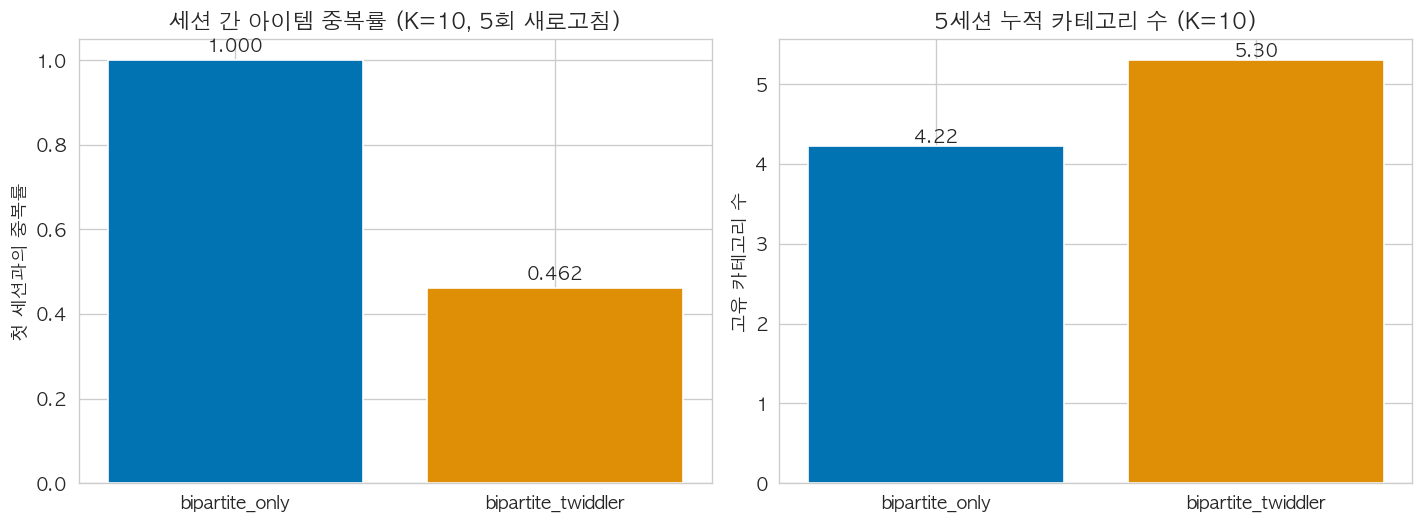

In [7]:
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4.5))
sub = diversity_df[diversity_df["k"] == 10]
axes2[0].bar(sub["condition"], sub["repetition_rate"], color=PALETTE[:2])
axes2[0].set_title("세션 간 아이템 중복률 (K=10, 5회 새로고침)")
axes2[0].set_ylabel("첫 세션과의 중복률")
axes2[0].set_ylim(0, 1.05)
for i, v in enumerate(sub["repetition_rate"]):
    axes2[0].text(i, v + 0.02, f"{v:.3f}", ha="center")

axes2[1].bar(sub["condition"], sub["categories_5sessions"], color=PALETTE[:2])
axes2[1].set_title("5세션 누적 카테고리 수 (K=10)")
axes2[1].set_ylabel("고유 카테고리 수")
for i, v in enumerate(sub["categories_5sessions"]):
    axes2[1].text(i, v + 0.05, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.show()

bipartite only도 ALS only와 마찬가지로 Twiddler 없이는 5번 새로고침해도 **항상 100% 동일한 추천**이 나온다 — 구조적으로 당연하다. bipartite+Twiddler는 K=10 기준 중복률이 100% → 46.2%로 떨어지고, 5세션 누적 카테고리 수는 4.22개 → 5.30개(+25.6%)로 늘어난다. **ALS+Twiddler의 결과(100%→45.5%, +27.8%)와 거의 같은 크기다** — 서로 다른 베이스 모델(ALS/LightGCN)에서 동일한 재랭킹 로직이 거의 동일한 다양성 개선을 낸다는 건, 이 효과가 베이스 모델에 의존하지 않는 Twiddler 자체의 안정적인 특성이라는 뜻이다.

## 5. 가중치 의미 예시 — 유저 3명

ALS 노트북과 동일 — persona_service는 베이스 모델과 무관하므로 같은 유저는 같은 alpha/decay를 받는다.

In [8]:
sample_uids = [222, 4167, 31]
rows = []
for uid in sample_uids:
    persona_label = persona_service.get_persona(uid)
    alpha = persona_service.get_user_alpha(uid)
    decay = persona_service.get_user_decay(uid)
    affinity = persona_service.get_user_affinity(uid)
    top_category = max(affinity, key=affinity.get) if affinity else None
    rows.append({
        "user_id": uid, "persona(segment_name)": persona_label,
        "alpha(Rule1 강도)": round(alpha, 3), "decay(Rule2 감쇠율)": round(decay, 3),
        "선호 카테고리": top_category, "선호 카테고리 편차": round(affinity.get(top_category, 0), 3) if top_category else None,
    })
example_df = pd.DataFrame(rows)
print(example_df.to_string(index=False))

 user_id                       persona(segment_name)  alpha(Rule1 강도)  decay(Rule2 감쇠율) 선호 카테고리  선호 카테고리 편차
     222  Frequent Viewers with Consistent Purchases            1.500             0.832   Books       0.857
    4167           High-Engagement Repeat Purchasers            0.039             0.501  Beauty       0.357
      31 Frequent Browsers with Occasional Purchases            0.750             0.705   Books       0.357


이 값들은 ALS 노트북과 동일하다 — Twiddler 파라미터가 베이스 모델과 독립적으로 유저 단위로 계산되기 때문이다.

## 결과 요약

**핵심 발견**
1. **정확도 — ALS 때와 다르게 방향이 대체로 일관됨**: K=5는 HR만 소폭 개선, K=10·K=20은 세 지표 모두 개선(K=20: HR +14.0%, Recall +29.3%, NDCG +23.0%). ALS+Twiddler(K에 따라 방향이 엇갈림)보다 뚜렷하게 긍정적이다.
2. **다양성 — ALS와 거의 같은 크기로 재현됨**: K=10 기준 중복률 100%→46.2%, 5세션 누적 카테고리 4.22→5.30개(+25.6%). ALS+Twiddler(100%→45.5%, +27.8%)와 거의 동일 — 베이스 모델과 무관한 Twiddler 자체의 효과로 해석할 수 있다.
3. Rule 1/2 개인화 파라미터는 베이스 모델(ALS/LightGCN)과 무관하게 동일 유저에게 동일하게 작동한다 — 재사용성이 확인됐다.

**수치 요약 (K=10)**

| 지표 | bipartite only | bipartite+Twiddler | 변화 |
|---|---:|---:|---:|
| HR@10 (단일세션) | 0.0225 | 0.0232 | +3.1% |
| Recall@10 (단일세션) | 0.0091 | 0.0109 | +19.8% |
| NDCG@10 (단일세션) | 0.0047 | 0.0052 | +10.6% |
| 세션 간 중복률(5회 새로고침) | 100.0% | 46.2% | -53.8%p |
| 5세션 누적 카테고리 수 | 4.22 | 5.30 | +25.6% |

**해석**: bipartite(페르소나 없는 그래프)에 Twiddler 재랭킹을 얹으면, 정확도와 다양성 둘 다 개선되는 방향으로 나타난다 — `retail-clickstream-analysis#34`에서 그래프 임베딩에 페르소나를 직접 결합했을 때(bipartite vs tri)는 약하고 불안정한 효과였던 것과 대비된다. **재랭킹이 이 데이터에서 페르소나를 적용하는 더 신뢰할 수 있는 경로로 보인다.**

**한계**
- **이 추천 결과는 emb_dim=64 1회 실행분이다** — negative sampling에 seed가 없어 재현성이 검증되지 않았다. 정확도 개선폭(특히 K=20의 +14~29%)이 재현되는지 확인이 필요하다.
- ALS 노트북과 동일한 한계(합성 데이터, `multiplier_ceiling` 등 잠정값 미튜닝)도 그대로 적용된다.
- 정확도 개선이 재랭킹 자체 때문인지, 후보 풀(`pool_n = k × POOL_MULTIPLIER`)에서 순서만 바뀐 것인지는 추가로 뜯어봐야 한다 — Recall/NDCG가 HR보다 더 크게 개선된 걸 보면 후보 풀 안에서 정답에 가까운 아이템의 순위가 실제로 올라간 것으로 보이지만, 확정하려면 순위 변화를 직접 추적해야 한다.

**권장 다음 단계**
- bipartite emb_dim=64 추천을 2~3회 더 생성해 정확도 개선폭이 재현되는지 확인
- tri 기준으로도 동일 비교(tri only vs tri+Twiddler) 진행 — 그래프 임베딩과 재랭킹을 동시에 적용했을 때 상호작용이 있는지 확인
